In [ ]:
# Define source path for journal results
SOURCE_PATH = "../../save_and_results/old/journal/"

In [13]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt

from utils.display_tools import load_best_forecasts,  display_predictions_2
from sklearn.metrics import r2_score
import matplotlib

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
lot = pickle.load(open("../../save_and_results/cache_lot.p", "rb"))
data = pickle.load(open("../../save_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../../save_and_results/cache_exogs.p", "rb"))

## Draw some point

In [16]:
d = data["Moehne"]["desc1"]
y_ = d.loc[d.index.year == 2020]

In [19]:
cm_subsection = linspace(0, 1, 7)
colors_add = iter([cm.Accent(x) for x in cm_subsection])

colors_add = list(colors_add)

colors = {
"ari":colors_add[3],
"for": colors_add[1],
"ada": colors_add[2],
"lin": colors_add[0],
"var": colors_add[4],
"chr": colors_add[5],
"tfm": colors_add[6]
}

/tmp/ipykernel_100600/1466039297.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  res = str(mae["1"].loc["lin"].round(2)[0])
/tmp/ipykernel_100600/1466039297.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  res = str(mae["1"].loc["lin"].round(2)[0])
/tmp/ipykernel_100600/1466039297.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  res = str(mae["1"].loc["lin"].round(2)[0])
/tmp/ipykernel_100600/1466039297.py:90: FutureWar

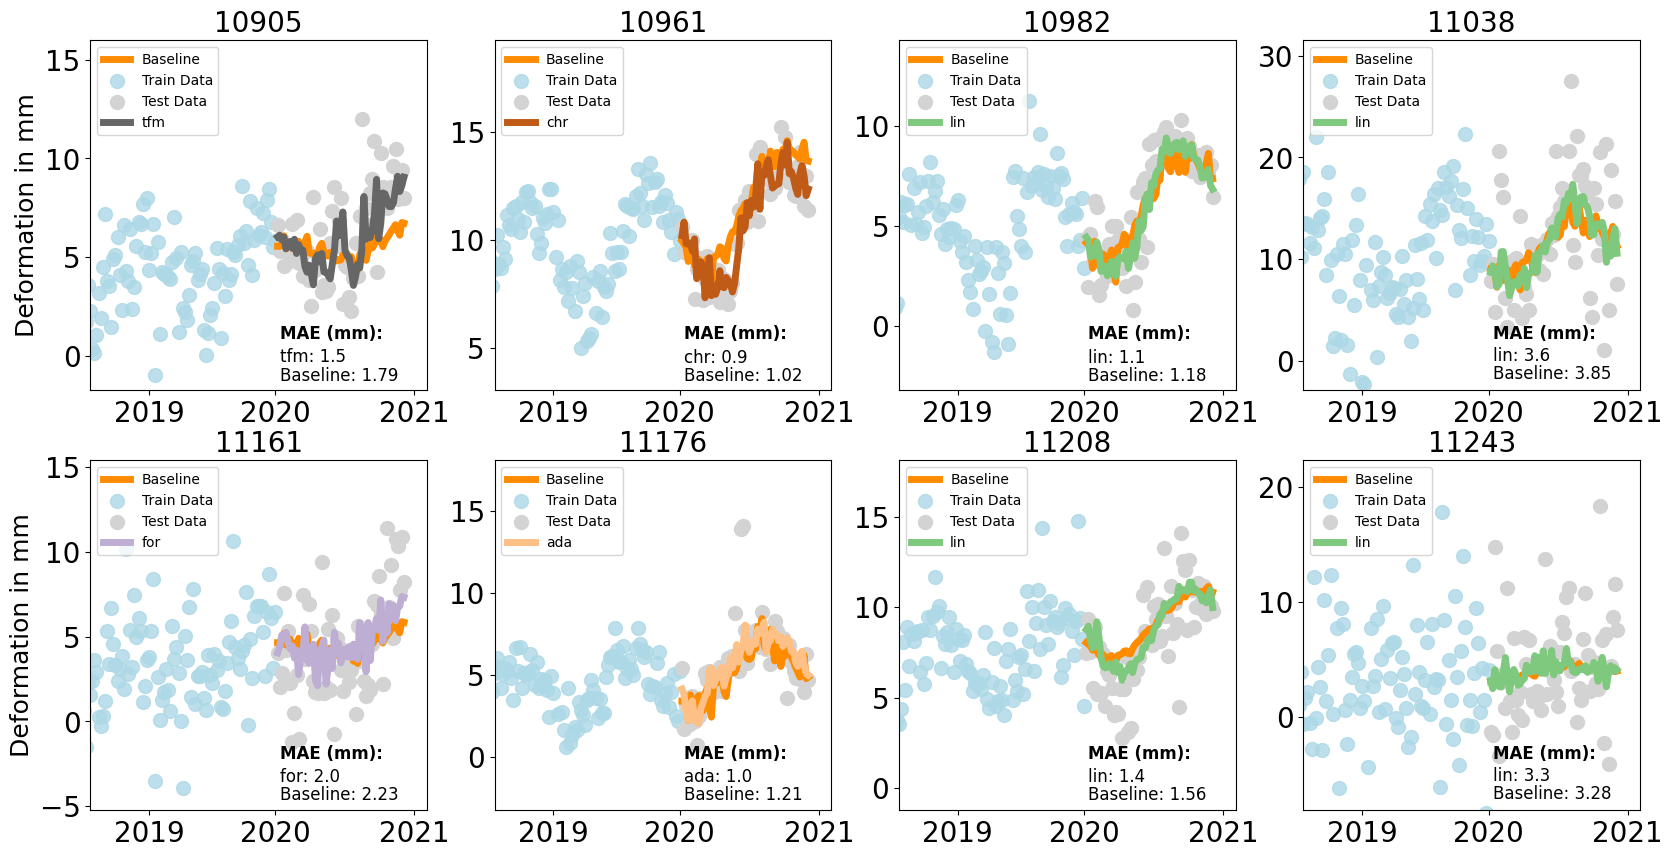

In [20]:
ms = {}
fc = {}
mae = {}

fig, axs = plt.subplots(2, 4, figsize=(20, 10))


for counter,ps_id in  enumerate(d.columns):

    for x in [str(n) for n in range(0,4)]:
        model_spec, forecasts = load_best_forecasts(SOURCE_PATH + x, direction="desc1")
        stack = []
        for model_type in forecasts.keys():
            stack.append(forecasts[model_type][ps_id])
        naming = forecasts.keys()
        forecasts = pd.concat(stack, axis=1)
        forecasts.columns = naming
        if (x == "1")  or (x == "2"):
            forecasts.drop(columns="sarimax", inplace=True)
        if x == "2":
            try:
                forecasts.drop(columns="var", inplace=True)
            except:
                pass

        score = pd.DataFrame(
            [np.abs(forecasts[x] - y_[ps_id].values).mean() for x in forecasts.columns],
            index=forecasts.columns,
            columns=["MAE"],
        )
        fc[x] = forecasts
        fc[x].columns = [x  if x != "sar" else "ari" for x in fc[x].columns.str[:3]]
        mae[x] = score
        mae[x].index = [x  if x != "sar" else "ari" for x in mae[x].index.str[:3]]
        mae[x] = score

    chronos = pd.read_csv(SOURCE_PATH + "chronos/Moehne_desc1_chronos_zero_shot_chronos.csv", index_col=0)[ps_id]
    tfm = pd.read_csv(SOURCE_PATH + "tfm/Moehne_desc1_tfm_zero_shot_chronos.csv", index_col=0)[ps_id]
    # append foundational models

    for study in ["0", "3"]:
        fc[study]["chr"] = chronos.values[:-1]
        fc[study]["tfm"] = tfm.values[:-1]

        mae[study] = mae[study].T

        mae[study]["chr"] = np.abs(y_[ps_id] - chronos.values[:-1]).mean()
        mae[study]["tfm"] = np.abs(y_[ps_id] - tfm.values[:-1]).mean()

        mae[study] = mae[study].T


    train = d.loc[d.index.year < 2020, ps_id].interpolate()
    test = d.loc[d.index.year == 2020, ps_id].interpolate()
    best = "lin"
    axs[0 if counter < 4 else 1,counter%4].plot(
        np.arange(len(train), len(train) + len(test)),
        fc["1"][best],
        color="darkorange",
        alpha=1,
        linewidth=5,
        label="Baseline",
    )


    display_predictions_2(
        fig,
        axs[0 if counter < 4 else 1,counter%4 ],
        d,
        fc["0"],
        y_[ps_id],
        mae["0"],
        colors=colors,
        fontsize=12,
        residual_plot=False,
        rs_fontsize=15,
        add_errors=True,
        error_coords=[90, 1.1, 1.17],
        rs_position=[310, -5],
        spacing=0.2,
        provided_axes=axs[0, 0],
        key=ps_id,
        only_best_error=True,
        shortening=False,
        x_lim=[200, 360],
        y_lim="Auto",
        marker="o",
    )

    res = str(mae["1"].loc["lin"].round(2)[0])
    to_add = axs[0 if counter < 4 else 1,counter%4]

    to_add.text(
        to_add.get_xlim()[0] + 90,
        to_add.get_ylim()[1] - ((to_add.get_ylim()[1] - to_add.get_ylim()[0]) / 1.04) - (0.2 * 1),
        (
            "Baseline" + ": " + res
        ),
        fontsize=12,
    )
    r2 = r2_score(y_[ps_id].values, fc["0"][best].values)
    axs[0 if counter < 4 else 1,counter%4].legend(loc=0, fontsize=10)
    axs[0 if counter < 4 else 1,counter%4].set_title(ps_id, fontsize=20)

for c in [(1,0), (0,0)]:
    axs[c].set_ylabel("Deformation in mm", fontsize=18)
plt.savefig("../../imgs/mdpi_2.pdf")